In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
import seaborn as sns

##**Loading the dataset**

In [ ]:
df1 = pd.read_csv('/content/gender_submission.csv')
print(df1.head(10))


   PassengerId  Survived
0          892         0
1          893         1
2          894         0
3          895         0
4          896         1
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0


In [153]:
df2=pd.read_csv('/content/test.csv')
print(df2.head(10))

   PassengerId  Pclass                                          Name     Sex  \
0          892       3                              Kelly, Mr. James    male   
1          893       3              Wilkes, Mrs. James (Ellen Needs)  female   
2          894       2                     Myles, Mr. Thomas Francis    male   
3          895       3                              Wirz, Mr. Albert    male   
4          896       3  Hirvonen, Mrs. Alexander (Helga E Lindqvist)  female   
5          897       3                    Svensson, Mr. Johan Cervin    male   
6          898       3                          Connolly, Miss. Kate  female   
7          899       2                  Caldwell, Mr. Albert Francis    male   
8          900       3     Abrahim, Mrs. Joseph (Sophie Halaut Easu)  female   
9          901       3                       Davies, Mr. John Samuel    male   

    Age  SibSp  Parch     Ticket     Fare Cabin Embarked  
0  34.5      0      0     330911   7.8292   NaN        Q  
1

In [ ]:
df3 = pd.read_csv('/content/train.csv')
print(df3.head(10))

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   
5            6         0       3   
6            7         0       1   
7            8         0       3   
8            9         1       3   
9           10         1       2   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   
5                                   Moran, Mr. James    male   NaN      0   
6                            McCarthy, Mr. Timothy J    male  54

##**Data Cleaning**

**Identifying and handling missing values**

In [ ]:
print(df3.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
 11  Age Group    891 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [ ]:
# Impute 'Age' with the median value
df3['Age'].fillna(df3['Age'].median(), inplace=True)


<ipython-input-18-96f96979ac2e>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df3['Age'].fillna(df3['Age'].median(), inplace=True)


In [ ]:
# Impute 'Embarked' with the mode value
df3['Embarked'].fillna(df3['Embarked'].mode()[0], inplace=True)

<ipython-input-19-69b7e107bf09>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df3['Embarked'].fillna(df3['Embarked'].mode()[0], inplace=True)


In [ ]:
# Drop the 'Cabin' column due to a high percentage of missing values
df3.drop(columns=['Cabin'], inplace=True)

In [ ]:

# Verify that missing values have been handled
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


**Searching for duplicate records**

In [ ]:
df3.duplicated().sum() #no duplicates

0

**No date related columns found**

**Creating new column for age groups**

In [ ]:
# Function to classify age groups
def age_group(age):
    if age < 18:
        return 'Child'
    elif 18 <= age < 60:
        return 'Adult'
    else:
        return 'Senior'


In [ ]:
# Creating the new column
df3['Age Group'] = df3['Age'].apply(age_group)


In [ ]:
print(df3.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Embarked Age Group  
0      0         A/5 21171   7.2500        S     Adult  
1      0          PC 17599  71.2833        C     Adult  
2      0  STON/O2. 3101282   7.9250        S     Adult  
3      0            113803  53.1000        S     Adult  
4      0            373450   8.0500

##**Exploratory data analysis**

**Summary of dataset**

In [ ]:
from tabulate import tabulate
summary = df3.describe(include='all')
summary_table = tabulate(summary, headers='keys', tablefmt='grid')

print(summary_table)


+--------+---------------+------------+------------+-------------------------+-------+----------+------------+------------+----------+----------+------------+-------------+
|        |   PassengerId |   Survived |     Pclass | Name                    | Sex   |      Age |      SibSp |      Parch |   Ticket |     Fare | Embarked   | Age Group   |
+========+===============+============+============+=========================+=======+==========+============+============+==========+==========+============+=============+
| count  |       891     | 891        | 891        | 891                     | 891   | 891      | 891        | 891        |      891 | 891      | 891        | 891         |
+--------+---------------+------------+------------+-------------------------+-------+----------+------------+------------+----------+----------+------------+-------------+
| unique |       nan     | nan        | nan        | 891                     | 2     | nan      | nan        | nan        |      681 | 

**Distribution of passengers**

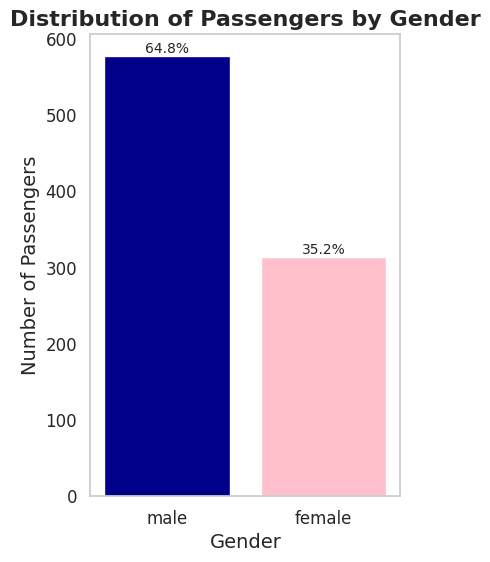

In [155]:
# Count the number of passengers by gender
gender_counts = df3['Sex'].value_counts()

# Calculate percentages
gender_percentages = (gender_counts / gender_counts.sum()) * 100

#create the bar plot
plt.figure(figsize=(4, 6))
bars = plt.bar(gender_counts.index, gender_counts.values, color=['darkblue', 'pink'])

plt.title('Distribution of Passengers by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Number of Passengers', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

for bar, percentage in zip(bars, gender_percentages):
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, yval,
        f'{percentage:.1f}%', ha='center', va='bottom', fontsize=10
    )

plt.grid(False)
plt.show()

**Age distribution**

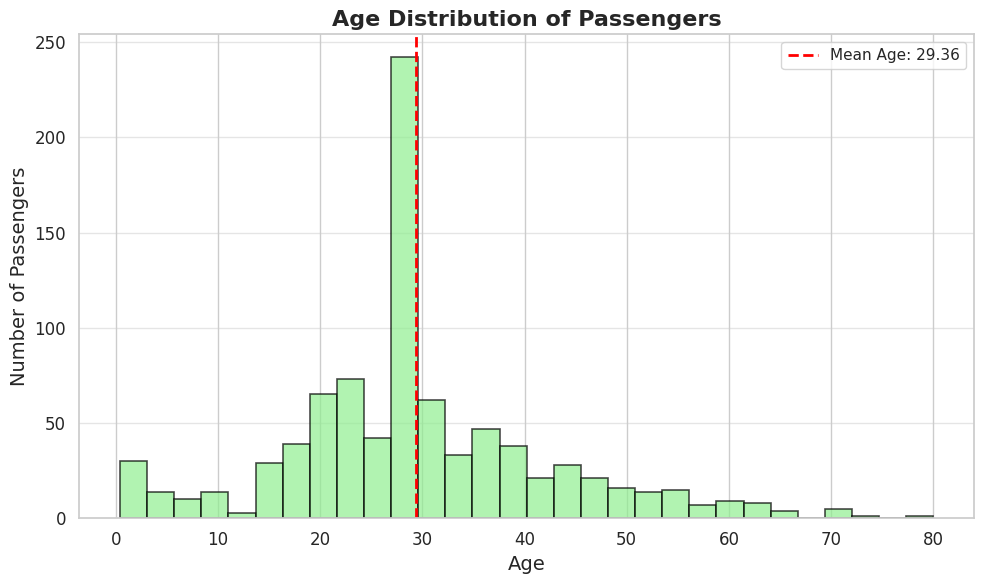

In [ ]:
plt.figure(figsize=(10, 6))
bins = 30

# Create the histogram
plt.hist(df3['Age'], bins=bins, edgecolor='black', alpha=0.7, color='lightgreen', linewidth=1.2)

plt.title('Age Distribution of Passengers', fontsize=16, fontweight='bold')
plt.xlabel('Age', fontsize=14)
plt.ylabel('Number of Passengers', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)


plt.grid(axis='y', alpha=0.5)

#age mean
mean_age = np.mean(df3['Age'])
plt.axvline(mean_age, color='red', linestyle='--', linewidth=2, label=f'Mean Age: {mean_age:.2f}')

plt.legend()
plt.tight_layout()
plt.show()

**Survival rate by gender**

Text(0.5, 1.0, 'Overall Survival Rate')

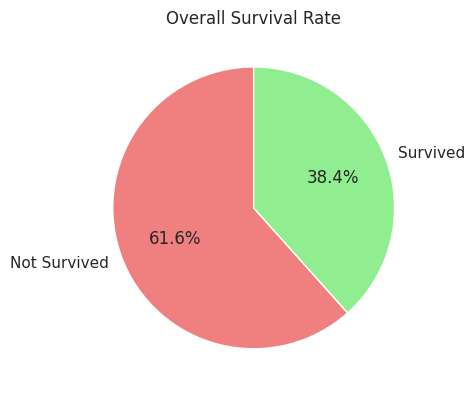

In [ ]:
plt.figure(figsize=(10, 5))

#pie chart for the overall survival rate
plt.subplot(1, 2, 1)  # 1 row, 2 columns, 1st subplot
survival_counts = df3['Survived'].value_counts()
labels = ['Not Survived', 'Survived']
colors = ['lightcoral', 'lightgreen']

plt.pie(survival_counts, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.title('Overall Survival Rate')

<ipython-input-156-54e0094c4d22>:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  bar_plot = sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df3, palette=custom_palette, ci=None)
<ipython-input-156-54e0094c4d22>:5: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  bar_plot = sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df3, palette=custom_palette, ci=None)


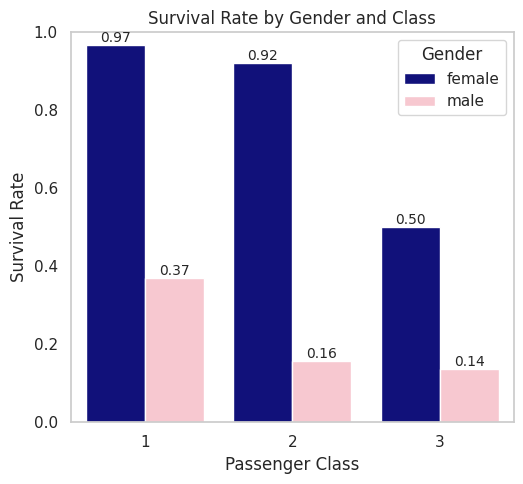

In [156]:
# Bar plot for survival rate by gender and class
custom_palette = ['darkblue', 'pink', '#99FF99']
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 2)
bar_plot = sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df3, palette=custom_palette, ci=None)
plt.title('Survival Rate by Gender and Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.legend(title='Gender')

for p in bar_plot.patches:
    height = p.get_height()
    if height > 0:
        bar_plot.annotate(f'{height:.2f}',
                          (p.get_x() + p.get_width() / 2., height),
                          ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.grid(False)
plt.show()


**Extra insights**

In [ ]:
age_group_data = df3.groupby('Age Group')['Survived'].mean()
age_group_percentages = age_group_data * 100
colors = ['salmon', 'lightblue', 'green']

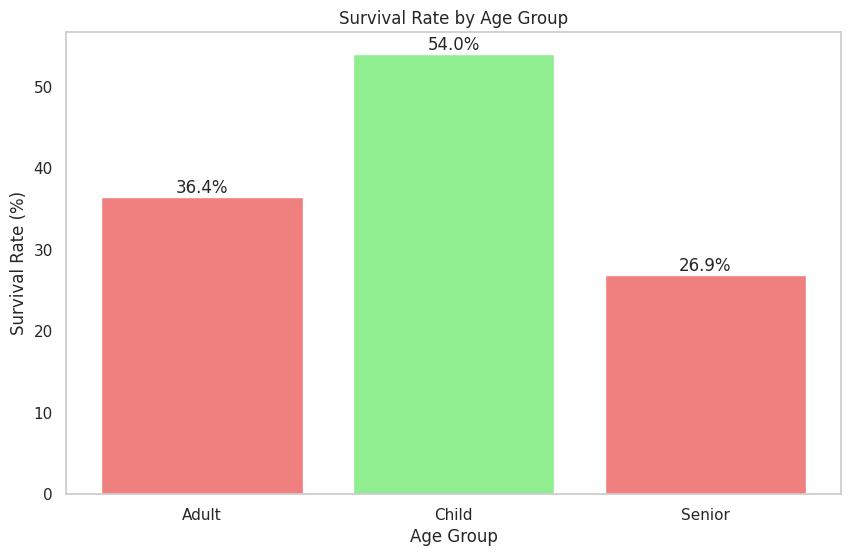

In [157]:
# Create the bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(age_group_percentages.index, age_group_percentages.values, color=colors)

plt.xlabel('Age Group')
plt.ylabel('Survival Rate (%)')
plt.title('Survival Rate by Age Group')

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2, yval,
        f'{yval:.1f}%', ha='center', va='bottom'
    )
plt.grid(False)
plt.show()

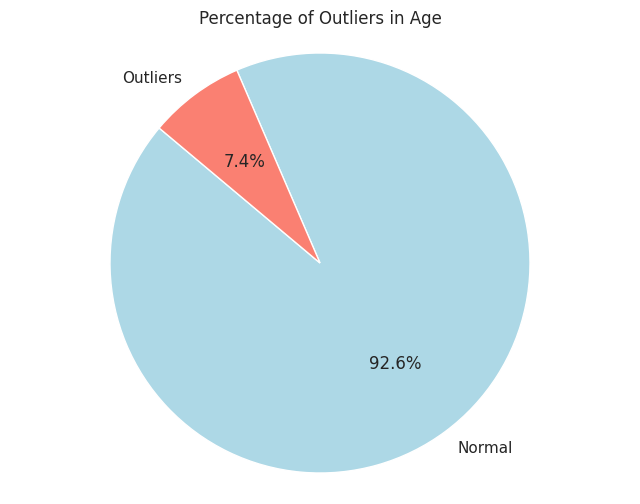

In [ ]:
# Get outliers
age_outliers = get_outliers(df3, "Age")
age_outlier_percentage = (len(age_outliers) / len(df3["Age"])) * 100
normal_percentage = 100 - age_outlier_percentage

# Plotting the percentages
labels = ['Normal', 'Outliers']
sizes = [normal_percentage, age_outlier_percentage]
colors = ['lightblue', 'salmon']

plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title('Percentage of Outliers in Age')
plt.axis('equal')
plt.show()


##**Basic Statistical Analysis**

In [141]:
# Calculate mean, median, and mode for 'Fare' and 'Age'
fare_mean = df3['Fare'].mean()
fare_median = df3['Fare'].median()
fare_mode = df3['Fare'].mode()[0]

age_mean = df3['Age'].mean()
age_median = df3['Age'].median()
age_mode = df3['Age'].mode()[0]

In [142]:
#DataFrame for the results
stats_df = pd.DataFrame({
    'Statistic': ['Mean', 'Median', 'Mode'],
    'Fare': [fare_mean, fare_median, fare_mode],
    'Age': [age_mean, age_median, age_mode]
})

stats_df.set_index('Statistic', inplace=True)
print(stats_df)

                Fare        Age
Statistic                      
Mean       32.204208  29.361582
Median     14.454200  28.000000
Mode        8.050000  28.000000


##**T-Test**

In [ ]:
from scipy import stats

male_survived = df3[df3['Sex'] == 'male']['Survived']
female_survived = df3[df3['Sex'] == 'female']['Survived']

# Perform the t-test
t_stat_survival_gender, p_value_survival_gender = stats.ttest_ind(male_survived, female_survived, equal_var=False)

print("T-Test for Survival Rate based on Gender:")
print(f"T-statistic: {t_stat_survival_gender}")
print(f"P-value: {p_value_survival_gender}")

# Conclusion
if p_value_survival_gender < 0.05:
    print("There is a significant difference in survival rates between male and female passengers.")
else:
    print("There is no significant difference in survival rates between male and female passengers.")


T-Test for Survival Rate based on Gender:
T-statistic: -18.67183317725917
P-value: 2.2836009226010533e-61
There is a significant difference in survival rates between male and female passengers.


In [143]:
# Calculate survival rates for males and females
male_survival_rate = df3[df3['Sex'] == 'male']['Survived'].mean() * 100
female_survival_rate = df3[df3['Sex'] == 'female']['Survived'].mean() * 100

print(f"Male Survival Rate: {male_survival_rate:.2f}%")
print(f"Female Survival Rate: {female_survival_rate:.2f}%")


Male Survival Rate: 18.89%
Female Survival Rate: 74.20%


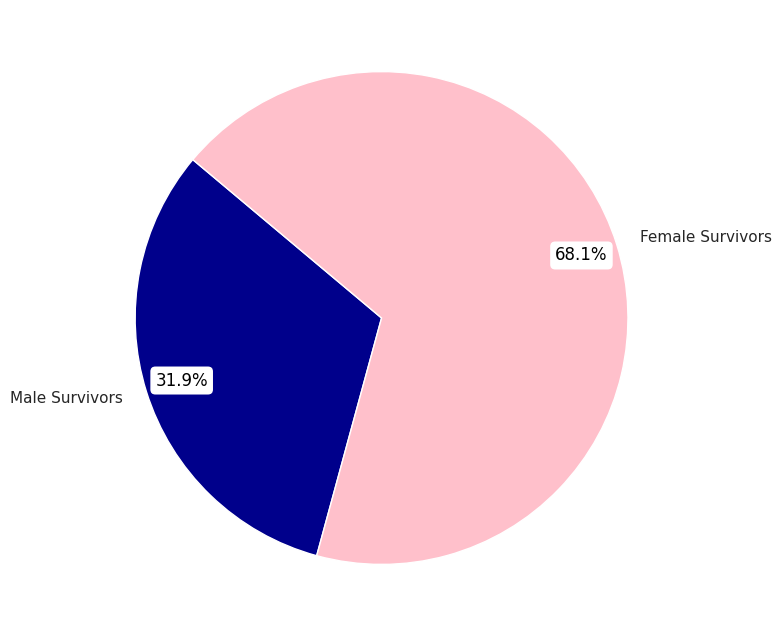

In [152]:
#visualize
labels = ['Male Survivors', 'Female Survivors']
sizes = [df3[(df3['Sex'] == 'male') & (df3['Survived'] == 1)].shape[0],
         df3[(df3['Sex'] == 'female') & (df3['Survived'] == 1)].shape[0]]

# Plotting the pie chart
plt.figure(figsize=(8, 8))
wedges, texts, autotexts = plt.pie(
    sizes,
    labels=labels,
    autopct=lambda p: f'{p:.1f}%',  # Custom function to format percentage
    startangle=140,
    colors=['darkblue', 'pink'],
    pctdistance=0.85  # Move percentage labels further out
)

#percentage labels with a white background
for text in autotexts:
    text.set_color('black')
    text.set_fontsize(12)
    text.set_bbox(dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.3'))


**Extra insight**

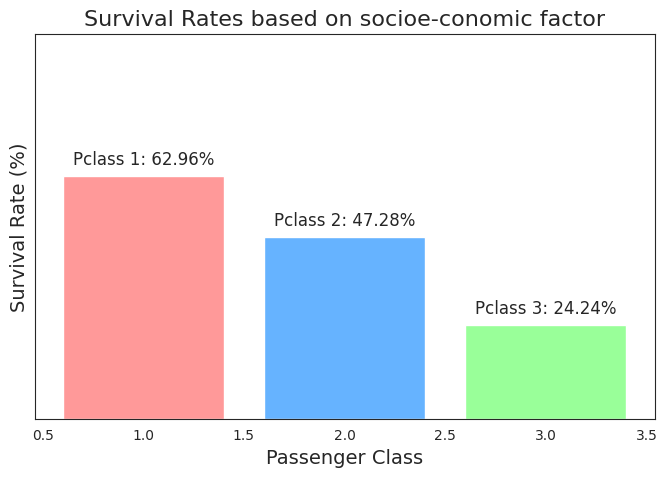

In [ ]:
# Calculate survival rates by passenger class
pclass_survival = df3.groupby('Pclass')['Survived'].mean() * 100

# Plotting the survival rates by passenger class
plt.figure(figsize=(8, 5))
bars = plt.bar(pclass_survival.index, pclass_survival.values, color=['#ff9999', '#66b3ff', '#99ff99'])
plt.title('Survival Rates based on socio-economic factor', fontsize=16)
plt.xlabel('Passenger Class', fontsize=14)
plt.ylabel('Survival Rate (%)', fontsize=14)
plt.ylim(0, 100)

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # Center the label on the bar
        yval + 2,  # Position slightly above the bar
        f"Pclass {int(bar.get_x() + 1)}: {yval:.2f}%",  # Get class number from x position
        ha='center',  # Center alignment
        va='bottom',  # Align at the bottom of the label
        fontsize=12
    )

plt.yticks([])

plt.show()


